In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем датасет напрямую из seaborn (он встроен)
df = sns.load_dataset('titanic')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [21]:
# Смотрим первые 5 строк
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
# Смотрим типы данных и пропуски
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [23]:
# Считаем пропуски в каждом столбце
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Создаём таблицу пропусков
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_percent
})

# Показываем только столбцы с пропусками
print(missing_df[missing_df['Missing_Count'] > 0])

             Missing_Count  Missing_Percent
age                    177        19.865320
embarked                 2         0.224467
deck                   688        77.216611
embark_town              2         0.224467


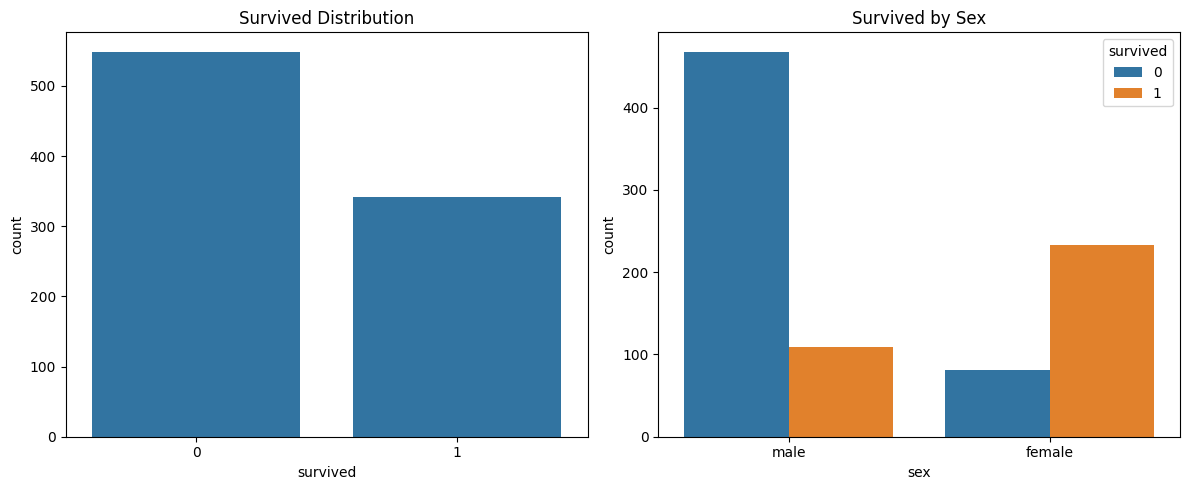

In [24]:
# 1. Распределение выживших
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='survived')
plt.title('Survived Distribution')

# 2. Выжившие по полу
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survived by Sex')

plt.tight_layout()
plt.show()

In [25]:
# Заполняем пропуски в Age медианой
df['age'] = df['age'].fillna(df['age'].median())

# Проверяем: пропусков в age должно стать 0
print(f"Age missing after fill: {df['age'].isnull().sum()}")

Age missing after fill: 0


In [26]:
# Находим самое частое значение в embarked
most_frequent = df['embarked'].mode()[0]
print(f"Most frequent port: {most_frequent}")

# Заполняем пропуски этим значением
df['embarked'] = df['embarked'].fillna(most_frequent)

# Проверяем
print(f"Embarked missing after fill: {df['embarked'].isnull().sum()}")

Most frequent port: S
Embarked missing after fill: 0


In [27]:
# В Deck больше 70% пропусков — проще удалить столбец
df = df.drop(columns=['deck'])
print(f"Deck removed. Remaining columns: {df.shape[1]}")

Deck removed. Remaining columns: 14


In [28]:
# Итоговая таблица пропусков
missing = df.isnull().sum()
print(missing[missing > 0])

# Если остались age_class или другие — пока оставляем, вернёмся позже

embark_town    2
dtype: int64


In [29]:
# Показываем колонки с текстовыми данными (тип object)
print(df.select_dtypes(include=['object', 'str']).columns.tolist())

['sex', 'embarked', 'who', 'embark_town', 'alive']


In [30]:
# Отбираем нужные колонки для модели
df_model = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

# Показываем первые строки
df_model.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [31]:
# Превращаем текст в числа через get_dummies
df_encoded = pd.get_dummies(df_model, columns=['sex', 'embarked'], drop_first=False)

# Показываем результат
print(df_encoded.columns.tolist())
df_encoded.head()

['survived', 'pclass', 'age', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


,survived,pclass,age,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,7.2500,False,True,False,False,True
1,1,1,38.0,71.2833,True,False,True,False,False
2,1,3,26.0,7.9250,True,False,False,False,True
3,1,1,35.0,53.1000,True,False,False,False,True
4,0,3,35.0,8.0500,False,True,False,False,True


In [32]:
# X — признаки, y — целевая переменная (выжил или нет)
X = df_encoded.drop(columns=['survived'])
y = df_encoded['survived']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (891, 8)
y shape: (891,)


In [33]:
from sklearn.model_selection import train_test_split

# Делим данные: 80% на обучение, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% данных уйдёт в тест
    random_state=42,    # Фиксируем случайность для воспроизводимости
    stratify=y          # Сохраняем баланс выживших/погибших в обеих выборках
)

# Проверяем размеры
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (712, 8), X_test: (179, 8)
y_train: (712,), y_test: (179,)


In [34]:
from sklearn.linear_model import LogisticRegression

# Создаём модель
model = LogisticRegression(random_state=42, max_iter=1000)

# Обучаем на train данных
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [35]:
# Предсказываем на тестовой выборке
y_pred = model.predict(X_test)

# Проверяем первые 10 предсказаний
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual:      {y_test.values[:10]}")

First 10 predictions: [0 0 0 0 1 0 1 0 0 0]
First 10 actual:      [0 0 1 0 1 1 1 0 0 0]


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Точность на тесте
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Матрица ошибок (сколько кого перепутали)
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

Accuracy on test set: 0.7709 (77.09%)
Confusion Matrix:
[[92 18]
 [23 46]]


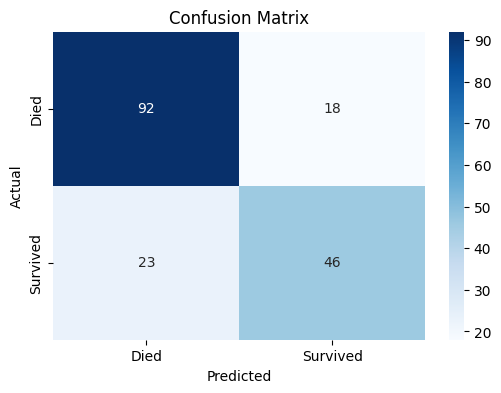

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [38]:
import joblib
import os

# Создаём папку для моделей (если нет)
os.makedirs('../models', exist_ok=True)

# Сохраняем модель
model_path = '../models/titanic_logreg.pkl'
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

# (Опционально) Сохраняем названия колонок — пригодится для предсказаний
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/titanic_features.pkl')
print(f"Feature names saved")

Model saved to ../models/titanic_logreg.pkl
Feature names saved


In [39]:
# Загружаем модель обратно
loaded_model = joblib.load('../models/titanic_logreg.pkl')
loaded_features = joblib.load('../models/titanic_features.pkl')

# Делаем предсказание на первых 5 строках теста
test_sample = X_test.head()
preds = loaded_model.predict(test_sample)
print(f"Predictions on test sample: {preds}")

Predictions on test sample: [0 0 0 0 1]
